In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [36]:
df = pd.read_csv("divorce.csv", sep=";")
print(df.head())

   Atr1  Atr2  Atr3  Atr4  Atr5  Atr6  Atr7  Atr8  Atr9  Atr10  ...  Atr46  \
0     2     2     4     1     0     0     0     0     0      0  ...      2   
1     4     4     4     4     4     0     0     4     4      4  ...      2   
2     2     2     2     2     1     3     2     1     1      2  ...      3   
3     3     2     3     2     3     3     3     3     3      3  ...      2   
4     2     2     1     1     1     1     0     0     0      0  ...      2   

   Atr47  Atr48  Atr49  Atr50  Atr51  Atr52  Atr53  Atr54  Class  
0      1      3      3      3      2      3      2      1      1  
1      2      3      4      4      4      4      2      2      1  
2      2      3      1      1      1      2      2      2      1  
3      2      3      3      3      3      2      2      2      1  
4      1      2      3      2      2      2      1      0      1  

[5 rows x 55 columns]


In [37]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Atr1,170.0,1.776471,1.627257,0.0,0.0,2.0,3.0,4.0
Atr2,170.0,1.652941,1.468654,0.0,0.0,2.0,3.0,4.0
Atr3,170.0,1.764706,1.415444,0.0,0.0,2.0,3.0,4.0
Atr4,170.0,1.482353,1.504327,0.0,0.0,1.0,3.0,4.0
Atr5,170.0,1.541176,1.632169,0.0,0.0,1.0,3.0,4.0
Atr6,170.0,0.747059,0.904046,0.0,0.0,0.0,1.0,4.0
Atr7,170.0,0.494118,0.898698,0.0,0.0,0.0,1.0,4.0
Atr8,170.0,1.452941,1.546371,0.0,0.0,1.0,3.0,4.0
Atr9,170.0,1.458824,1.557976,0.0,0.0,1.0,3.0,4.0
Atr10,170.0,1.576471,1.421529,0.0,0.0,2.0,3.0,4.0


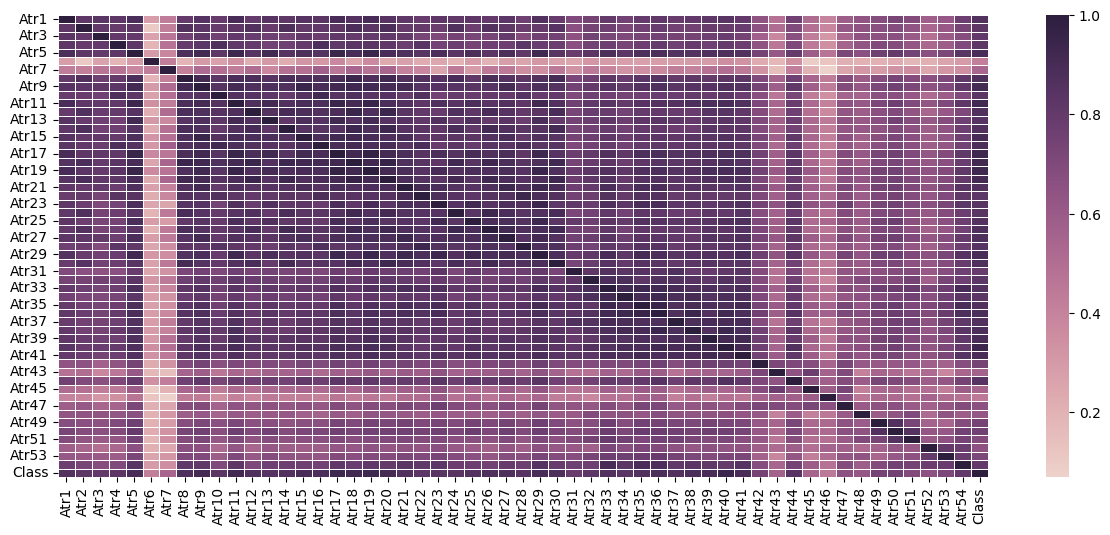

In [38]:
plt.figure(figsize=(15,6)) #plot the heatmap for the correlation
sns.heatmap(df.corr(),fmt=".5f", linewidth=.5, cmap=sns.cubehelix_palette(as_cmap=True)) 
plt.show() #the more darker color the more stronger correlation.

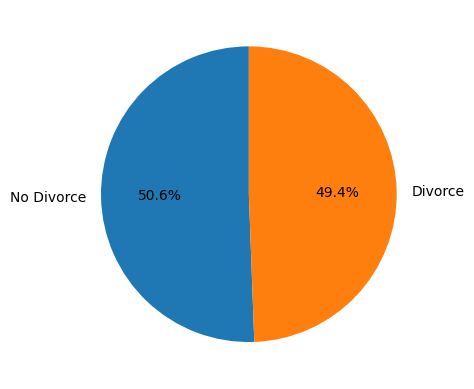

In [39]:
plt.pie(df['Class'].value_counts(), labels=['No Divorce', 'Divorce'], autopct='%1.1f%%', startangle=90)
plt.show()

In [40]:
df.corr()['Class'].sort_values(ascending=False).head(20) 

Class    1.000000
Atr40    0.938684
Atr17    0.929346
Atr19    0.928627
Atr18    0.923208
Atr11    0.918386
Atr9     0.912368
Atr20    0.907008
Atr15    0.901220
Atr39    0.896180
Atr41    0.894356
Atr5     0.893180
Atr29    0.892954
Atr36    0.886497
Atr16    0.886260
Atr38    0.883311
Atr30    0.874531
Atr26    0.872868
Atr27    0.869788
Atr8     0.869569
Name: Class, dtype: float64

## AS WE CAN SEE THESE QUESTIONS ARE VERY CORRELATED 

In [41]:
corr_matrix = df.corr()
columns_to_drop = corr_matrix[corr_matrix['Class'] < 0.90].index

In [42]:
df2 = df.drop(columns=columns_to_drop)
print(df2.head())

   Atr9  Atr11  Atr15  Atr17  Atr18  Atr19  Atr20  Atr40  Class
0     0      1      0      0      0      0      1      3      1
1     4      4      4      4      4      3      2      4      1
2     1      3      3      3      3      3      2      3      1
3     3      4      3      3      3      3      4      4      1
4     0      0      1      1      1      2      1      1      1


<Axes: >

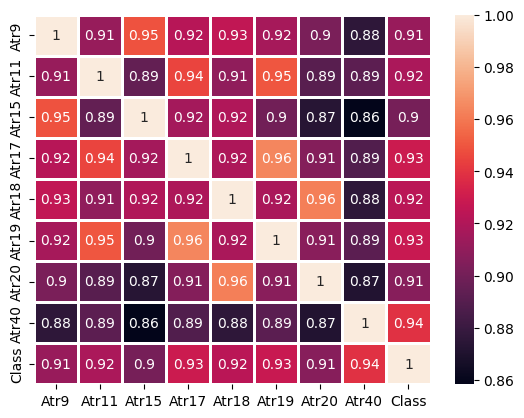

In [43]:
sns.heatmap(df2.corr(),annot = True, linewidths = 0.9)

In [44]:
X = df2.drop(columns=['Class'])
y = df2['Class']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
models = {
    'Random Forest Classifier': RandomForestClassifier(random_state=42),
    'XGBoost Classifier': XGBClassifier(random_state=42),
    'Extra Tree Classifier': ExtraTreesClassifier(random_state=42),
    'Decision Tree Classifier': DecisionTreeClassifier(random_state=42),
    'Gradient Boosting Classifier': GradientBoostingClassifier(random_state=42),
    'Ada Boost Classifier': AdaBoostClassifier(random_state=42)
}

In [48]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(name)
    print(f'Accuracy: {accuracy_score(y_test, y_pred):.3f}')
    print(classification_report(y_test, y_pred))
    print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
    print("-" * 50)

Random Forest Classifier
Accuracy: 0.971
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      0.95      0.97        20

    accuracy                           0.97        34
   macro avg       0.97      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34

Confusion Matrix:
 [[14  0]
 [ 1 19]]
--------------------------------------------------
XGBoost Classifier
Accuracy: 0.971
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      0.95      0.97        20

    accuracy                           0.97        34
   macro avg       0.97      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34

Confusion Matrix:
 [[14  0]
 [ 1 19]]
--------------------------------------------------
Extra Tree Classifier
Accuracy: 0.971
              precision    recall  f1-score   support
